# Logistic Regression: Heart Disease Prediction (Framingham)

**Dataset**: framingham.csv
**Algorithm**: Logistic Regression
**Objective**: Predict 10-year CHD risk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import pickle

print("✅ Libraries imported!")

✅ Libraries imported!


## 2. Data Loading

In [2]:
df = pd.read_csv('framingham.csv')
print(f"Shape: {df.shape}")
print(df.head())
print(df['TenYearCHD'].value_counts())

Shape: (4238, 16)
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  


## 3. Data Preprocessing

In [3]:
# Handle missing values
print(f"Missing before: {df.isnull().sum().sum()}")
df = df.dropna()
print(f"Missing after: {df.isnull().sum().sum()}")

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

print(f"\nFeatures: {len(X.columns)} features")

Missing before: 645
Missing after: 0

Features: 15 features


## 4. Train-Test Split & Pipeline

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

pipeline.fit(X_train, y_train)
print("✅ Logistic Regression Model trained!")

✅ Logistic Regression Model trained!


## 5. Evaluation

In [5]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No CHD', 'CHD']))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

      No CHD       0.84      0.99      0.91       610
         CHD       0.56      0.08      0.14       122

    accuracy                           0.84       732
   macro avg       0.70      0.53      0.53       732
weighted avg       0.80      0.84      0.78       732


Accuracy: 0.8361
Precision: 0.5556
Recall: 0.0820
F1 Score: 0.1429
ROC-AUC: 0.6994


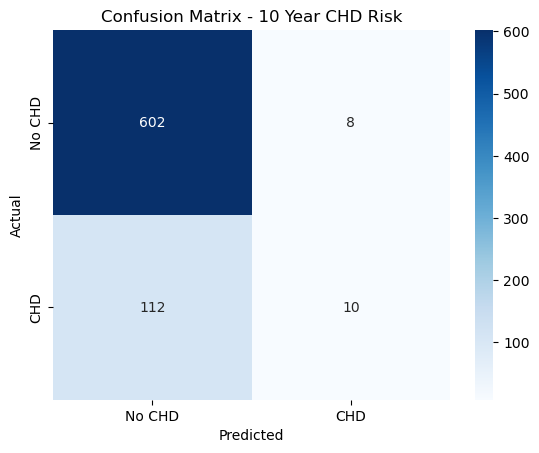

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD', 'CHD'],
            yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - 10 Year CHD Risk')
plt.show()

## 6. Save Model

In [7]:
with open('08_framingham_logistic_regression.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("✅ Saved: 08_framingham_logistic_regression.pkl")

✅ Saved: 08_framingham_logistic_regression.pkl
